# 🫀 Heart Disease Risk Prediction

## Machine Learning Based Heart Disease Risk Prediction System

This project uses Machine Learning techniques to predict the risk of
heart disease based on clinical and health-related parameters.

### Project Objectives

- Analyze the heart disease dataset
- Perform data cleaning and preprocessing
- Explore important patterns using EDA
- Train multiple Machine Learning models
- Compare model performance
- Select the best performing model
- Evaluate the selected model using different metrics
- Save the final model for deployment

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# To save the trained model
import joblib

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Load the heart disease dataset
# heart.csv is present in the same folder as this notebook

df = pd.read_csv("heart.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
# Display the first 5 rows of the dataset

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
# Display number of rows and columns

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nDataset Information:")
df.info()

Number of Rows: 918
Number of Columns: 12

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [12]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

# Total missing values
print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total Missing Values: 0


In [14]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

# Remove duplicates if any are present
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicate records removed.")
else:
    print("No duplicate records found.")

print("Updated Dataset Shape:", df.shape)

Number of Duplicate Records: 0
No duplicate records found.
Updated Dataset Shape: (918, 12)


In [16]:
# Display statistical summary of numerical columns

df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Heart Disease Distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64


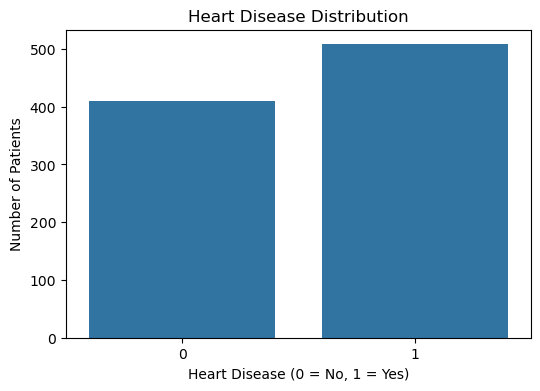

In [18]:
# HeartDisease is our target variable
# 0 = No Heart Disease
# 1 = Heart Disease

print("Heart Disease Distribution:")
print(df["HeartDisease"].value_counts())

# Visualize target variable
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="HeartDisease")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

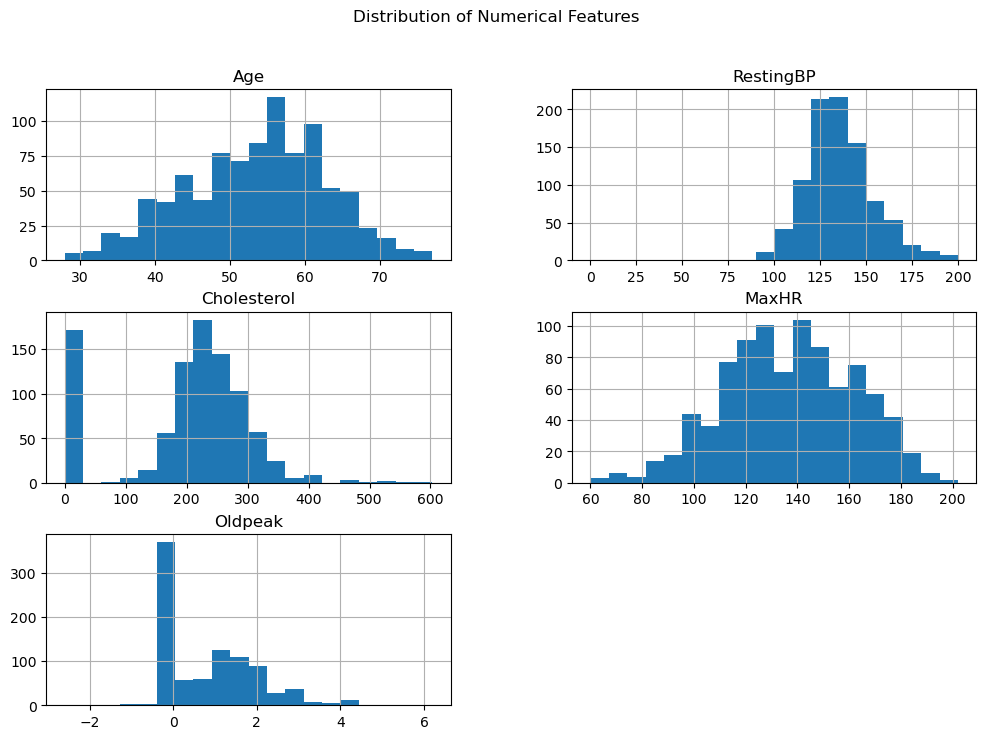

In [20]:
# Select numerical columns

numerical_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]

# Create distribution plots for numerical features

df[numerical_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

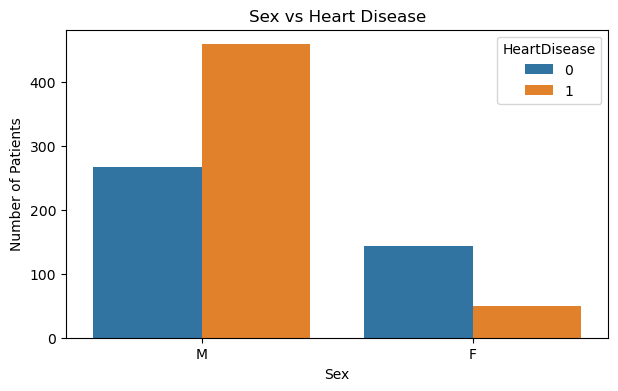

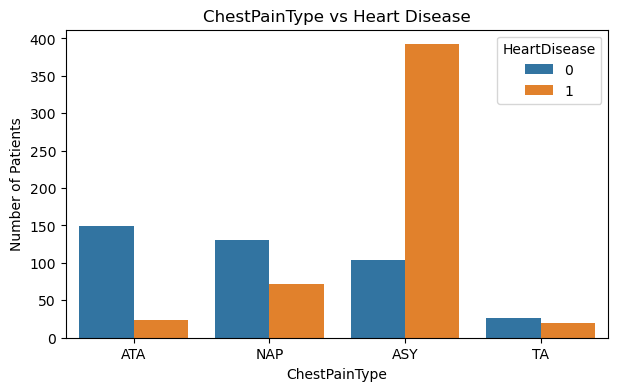

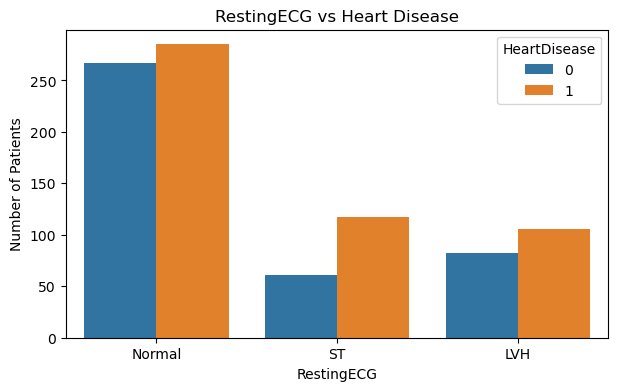

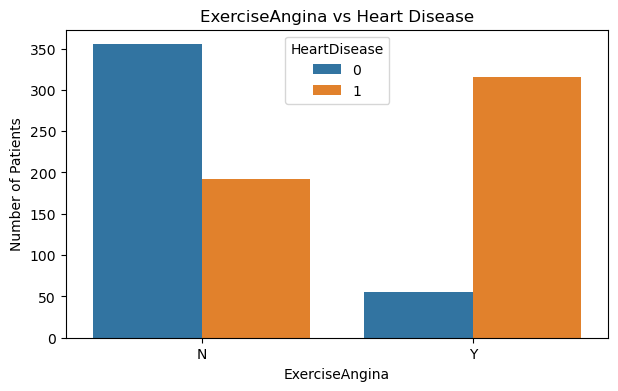

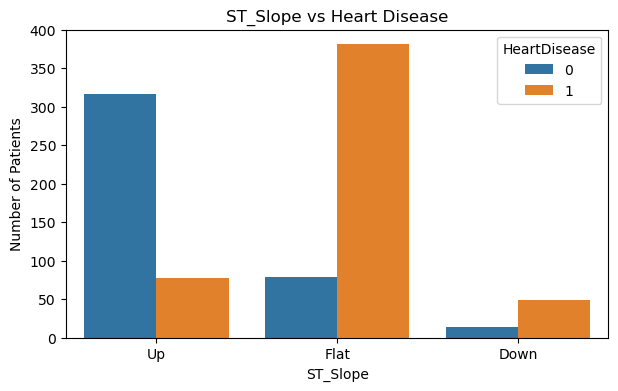

In [22]:
# Select important categorical columns

categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

# Plot categorical features

for column in categorical_columns:

    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=column,
        hue="HeartDisease"
    )

    plt.title(f"{column} vs Heart Disease")
    plt.xlabel(column)
    plt.ylabel("Number of Patients")

    plt.show()

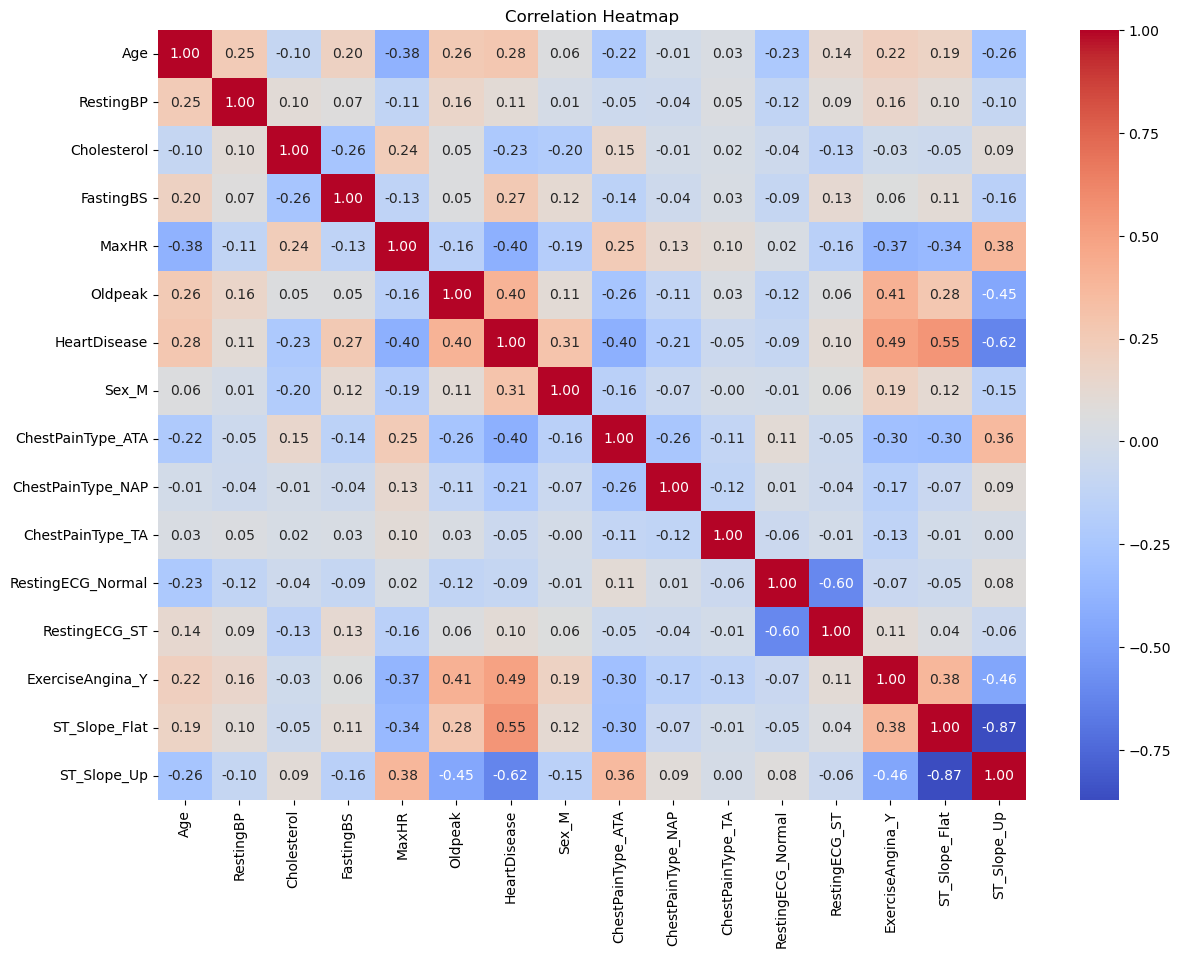

In [24]:
# Convert categorical columns into numeric values
# This is only for correlation analysis

correlation_data = pd.get_dummies(
    df,
    drop_first=True
)

# Calculate correlation matrix

correlation_matrix = correlation_data.corr()

# Display heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [26]:
# Separate input features and target variable

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

# Preprocessing:
# Numerical data -> StandardScaler
# Categorical data -> OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("\nPreprocessing setup completed!")

Numerical Features:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical Features:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Preprocessing setup completed!


In [28]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Records:", X_train.shape[0])
print("Testing Records:", X_test.shape[0])

Training Records: 734
Testing Records: 184


In [30]:
# Define multiple Machine Learning models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),
    
    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    )
}

# Dictionary to store trained pipelines

trained_models = {}

# Train each model

for name, model in models.items():

    # Create preprocessing + model pipeline
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train the model
    pipeline.fit(X_train, y_train)

    # Store trained pipeline
    trained_models[name] = pipeline

    print(f"{name} trained successfully!")

print("\nAll models trained successfully!")

Logistic Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!
K-Nearest Neighbors trained successfully!
Support Vector Machine trained successfully!

All models trained successfully!


In [32]:
# Compare the performance of all trained models

results = []

for name, model in trained_models.items():

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Calculate ROC-AUC
    y_probability = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_probability)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

# Create comparison table

results_df = pd.DataFrame(results)

# Sort models by F1 Score

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

  File "D:\Users\Excel\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\Users\Excel\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Users\Excel\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\Users\Excel\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.902174,0.896226,0.931373,0.913462,0.933106
1,Support Vector Machine,0.896739,0.887850,0.931373,0.909091,0.949426
2,K-Nearest Neighbors,0.896739,0.910891,0.901961,0.906404,0.943089
3,Logistic Regression,0.885870,0.871560,0.931373,0.900474,0.929938
4,Decision Tree,0.793478,0.813725,0.813725,0.813725,0.791009


In [34]:
# Select the best model based on F1 Score

best_model_name = results_df.loc[0, "Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

# Make predictions using the best model

y_pred_best = best_model.predict(X_test)

# Display classification report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best
    )
)

Best Model: Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        82
           1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



Confusion Matrix:
[[71 11]
 [ 7 95]]


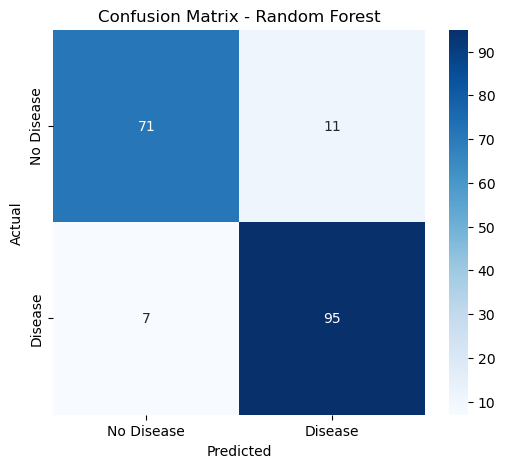

In [36]:
# Calculate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred_best
)

print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC-AUC Score: 0.9331


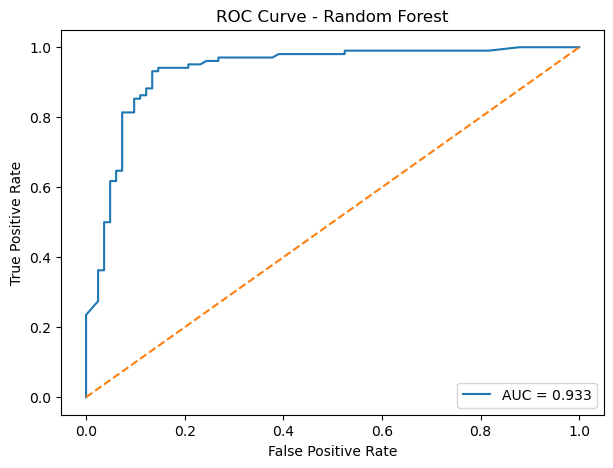

In [38]:
# Get probability predictions for the positive class

y_probability = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

# Calculate AUC score

auc_score = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", round(auc_score, 4))

# Plot ROC curve

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(f"ROC Curve - {best_model_name}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [40]:
# Save the complete trained model pipeline
# The pipeline already contains preprocessing + model

joblib.dump(
    best_model,
    "heart_disease_model.pkl"
)

# Save the preprocessing object separately as well
# This can be useful during deployment

joblib.dump(
    best_model.named_steps["preprocessor"],
    "preprocessor.pkl"
)

# Save the name of the selected model

with open("best_model_name.txt", "w") as file:
    file.write(best_model_name)

print("======================================")
print("Model saved successfully!")
print("Best Model:", best_model_name)
print("======================================")

print("\nFiles created:")

print("1. heart_disease_model.pkl")
print("2. preprocessor.pkl")
print("3. best_model_name.txt")

Model saved successfully!
Best Model: Random Forest

Files created:
1. heart_disease_model.pkl
2. preprocessor.pkl
3. best_model_name.txt
